<a href="https://colab.research.google.com/github/ahmed-zunaira/UTAT-Onboarding-Project/blob/main/UTAT_DL_Onboarding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importing libraries
import numpy as np
import csv
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torch.optim as optim
from sklearn.metrics import r2_score
from torch.utils.data import TensorDataset, DataLoader, random_split

In [ ]:
# loading the data
file_path = "/content/simpler_data_rwc.csv"
with open(file_path, 'r') as csvfile:
  data_reader = csv.reader(csvfile)

  data = []
  for row in data_reader:
    data.append(row)

data_np = np.array(data)
data_tensor = torch.from_numpy (data_np[1:,7:].astype(np.float32))
labels_tensor = torch.from_numpy (data_np[1:, 1:4].astype(np.float32))

# splitting data
dataset = TensorDataset(data_tensor, labels_tensor)
data_train, data_val, data_test = random_split(dataset, [0.7, 0.15, 0.15])

train_dataloader = DataLoader(data_train, batch_size=32, shuffle=True)
val_dataloader = DataLoader (data_val, batch_size=32, shuffle=True)
test_dataloader = DataLoader (data_test, batch_size=32, shuffle=True)

In [ ]:
# defining an MLP with two hidden layers
class MLP (nn.Module):
  def __init__ (self):
    super (MLP, self).__init__()
    self.layer1 = nn.Linear(210, 128)
    self.layer2 = nn.Linear (128, 128)
    self.layer3 = nn.Linear (128, 3)

  def forward(self, specs):
    activation1 = self.layer1(specs)
    activation1 = F.relu(activation1)
    activation2 = self.layer2(activation1)
    activation2 = F.relu(activation2)
    activation3 = self.layer3(activation2)
    output = torch.softmax(activation3, dim=-1)
    return output

def plot_loss(epochs):
  val_loss = np.loadtxt("model_MLP_epoch{}_val_loss.csv".format(epochs))
  train_loss = np.loadtxt("model_MLP_epoch{}_train_loss.csv".format(epochs))

  plt.title("Train & Validation Loss")

  plt.plot (range(1, epochs+1), train_loss, label="Train")
  plt.plot (range(1, epochs+1), val_loss, label="Validation")

  plt.xlabel ("Epoch")
  plt.ylabel("Loss")
  plt.legend(loc='best')
  plt.show()

def plot_r2 (data_type, epochs):
  r2_values = np.loadtxt("model_MLP_epoch{}_{}_r2.csv".format(epochs, data_type))

  plt.title ("Predicted vs. True Abundances: Validation (R-Squared)")

  plt.plot (range(1, epochs+1), r2_values)

  plt.xlabel ("Epoch")
  plt.ylabel("R-Squared Value")
  plt.show()

def plot_test ():
  true_values = np.loadtxt("model_MLP_test_output_true.csv")
  predicted_values = np.loadtxt("model_MLP_test_output_prediction.csv")

  plt.title ("Predicted vs. True Abundances: Testing")

  plt.scatter(true_values[:,0], predicted_values[:,0], color='green', label='GV')
  plt.scatter(true_values[:,1], predicted_values[:,1], color='red', label='NPV')
  plt.scatter(true_values[:,2], predicted_values[:,2], color='brown', label='Soil')

  min_val = np.min(true_values)
  max_val = np.max(true_values)
  plt.plot ([min_val, max_val], [min_val, max_val], linestyle='--')

  plt.legend(loc='best')

  plt.xlabel("True Abundance")
  plt.ylabel("Predicted Abundance")

  plt.show()

def test_MLP (net, test_dataloader):
  total_loss_test = 0.0
  model_outputs = []
  labels_test = []

  net.eval()

  criterion = nn.MSELoss()

  for i, (inputs, labels) in enumerate(test_dataloader):
    outputs = net(inputs)
    model_outputs.append(outputs.detach().numpy())
    labels_test.append(labels.detach().numpy())
    loss_test = criterion (outputs, labels.float())

    total_loss_test += loss_test.item()

  labels_test = np.vstack(labels_test)
  model_outputs = np.vstack(model_outputs)

  r2 = r2_score (labels_test, model_outputs)
  loss = total_loss_test / (i+1)

  np.savetxt ("model_MLP_test_output_true.csv", labels_test)
  np.savetxt ("model_MLP_test_output_prediction.csv", model_outputs)

  return r2, loss


# evaluating the model on validation data
def evaluate_MLP (net, val_dataloader, criterion):
  total_loss_val = 0.0
  model_outputs = []
  labels_val = []

  net.eval()

  for i, (inputs, labels) in enumerate(val_dataloader):
    outputs = net(inputs)
    model_outputs.append(outputs.detach().numpy())
    labels_val.append(labels.detach().numpy())
    loss_val = criterion (outputs, labels.float())

    total_loss_val += loss_val.item()

  r2 = r2_score (np.vstack(labels_val), np.vstack(model_outputs))
  loss = total_loss_val / (i+1)

  return r2, loss


# defining training function for model
def train_MLP (net, train_dataloader, val_dataloader, num_epochs=30):
  # setting manual seed for replication
  torch.manual_seed(1)
  best_epoch = 0
  best_val_r2 = 0

  # setting loss function and optimizer
  criterion = nn.MSELoss()
  optimizer = optim.AdamW(net.parameters())

  # setting up arrays to store losses over epochs
  train_loss = np.zeros(num_epochs)
  val_loss = np.zeros(num_epochs)
  val_r2 = np.zeros(num_epochs)

  start_time = time.time()

  for epoch in range(num_epochs):
    net.train()
    total_loss_train = 0.0

    for i, (inputs, labels) in enumerate(train_dataloader):

      optimizer.zero_grad()

      outputs = net(inputs)

      loss = criterion(outputs, labels.float())
      loss.backward()

      optimizer.step()

      total_loss_train += loss.item()

    train_loss[epoch] = float(total_loss_train) / (i+1)
    val_r2[epoch], val_loss[epoch] = evaluate_MLP (net, val_dataloader, criterion)

    if (val_r2[epoch] > best_val_r2):
      best_val_r2= val_r2[epoch]
      best_epoch = epoch+1

    print (("Epoch {}: Train loss: {}, Validation loss: {}, Validation r2: {}").format(epoch+1, train_loss[epoch], val_loss[epoch], val_r2[epoch]))
    torch.save(net.state_dict(), "model_MLP_epoch{}".format(epoch+1))

  print ("Training is complete.")
  end_time = time.time()
  total_time = end_time - start_time

  print ("Total time: {:.2f} seconds". format(total_time))

  # putting training & validation loss + loss r^2 values in files to plot after
  np.savetxt ("model_MLP_epoch{}_train_loss.csv".format(num_epochs), train_loss)
  np.savetxt ("model_MLP_epoch{}_val_loss.csv".format(num_epochs), val_loss)
  np.savetxt ("model_MLP_epoch{}_val_r2.csv".format(num_epochs), val_r2)

  return best_epoch


In [ ]:
mlp = MLP()

epoch_val = train_MLP(mlp, train_dataloader, val_dataloader, 100)

Epoch 1: Train loss: 0.0716099101853998, Validation loss: 0.05712377569741673, Validation r2: 0.44213560223579407
Epoch 2: Train loss: 0.04958700320046199, Validation loss: 0.062095575862460665, Validation r2: 0.48946189880371094
Epoch 3: Train loss: 0.04786271856803643, Validation loss: 0.04740882582134671, Validation r2: 0.5318009257316589
Epoch 4: Train loss: 0.043638896589216436, Validation loss: 0.03913768960369958, Validation r2: 0.5735761523246765
Epoch 5: Train loss: 0.040838789341873245, Validation loss: 0.03516186142547263, Validation r2: 0.6182094812393188
Epoch 6: Train loss: 0.04157797105022167, Validation loss: 0.03617035783827305, Validation r2: 0.6323287487030029
Epoch 7: Train loss: 0.03727773130920373, Validation loss: 0.032938284799456596, Validation r2: 0.6410540342330933
Epoch 8: Train loss: 0.03394074738025665, Validation loss: 0.03127616292072667, Validation r2: 0.681446373462677
Epoch 9: Train loss: 0.03277282892285209, Validation loss: 0.026554944821529917, Val

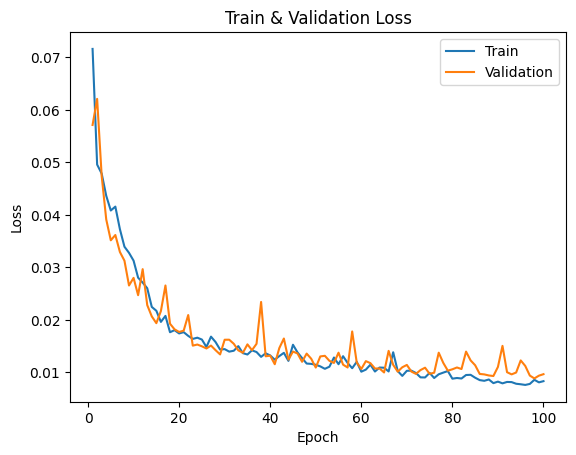

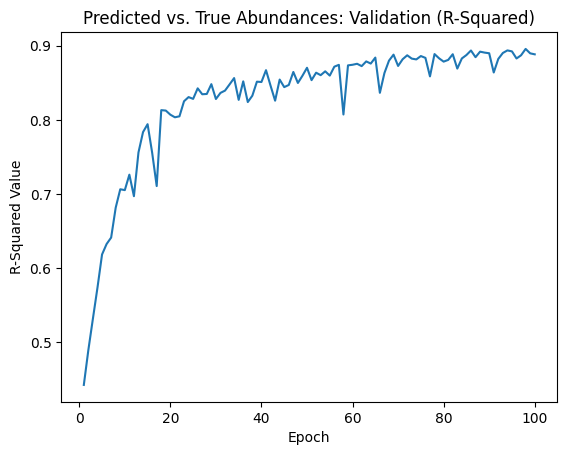

In [ ]:
plot_loss(100)
plot_r2('val', 100)

Epoch 1: Train loss: 0.07015965702502351, Validation loss: 0.05529507415162192, Validation r2: 0.4655732214450836
Epoch 2: Train loss: 0.04875822791731671, Validation loss: 0.061239828252130084, Validation r2: 0.4988149106502533
Epoch 3: Train loss: 0.0470742089183707, Validation loss: 0.045573181576199, Validation r2: 0.5504445433616638
Epoch 4: Train loss: 0.042604613215907625, Validation loss: 0.03810187801718712, Validation r2: 0.5852105021476746
Epoch 5: Train loss: 0.039869921478001696, Validation loss: 0.03357054044802984, Validation r2: 0.6329140663146973
Epoch 6: Train loss: 0.03999310540721605, Validation loss: 0.03476034042735895, Validation r2: 0.6407685279846191
Epoch 7: Train loss: 0.03499304951707784, Validation loss: 0.02959890192788508, Validation r2: 0.6760633587837219
Epoch 8: Train loss: 0.03144614996486589, Validation loss: 0.028659998542732663, Validation r2: 0.7067341804504395
Epoch 9: Train loss: 0.028776208183875208, Validation loss: 0.02637583459727466, Valida

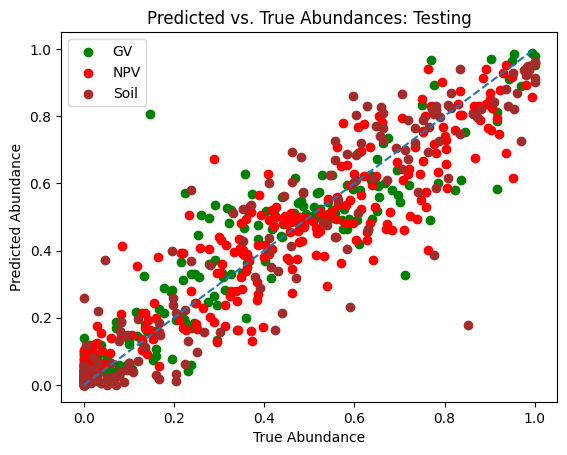

In [ ]:
mlp = MLP()

train_MLP(mlp, train_dataloader, val_dataloader, epoch_val)

test_r2, test_loss = test_MLP(mlp, test_dataloader)

print ("R-Squared value of testing data:", test_r2)
plot_test()